# 黄色边界面要素提取

本notebook用于从地图图片中提取黄色边界，生成闭合的面要素（Polygon），保存为ArcMap兼容的shapefile格式。

## 1. 导入必要的库

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import json
import pandas as pd
import os
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.ops import unary_union
import geopandas as gpd
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 确保输出目录存在
output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"已创建输出目录: {output_dir}")
else:
    print(f"输出目录已存在: {output_dir}")

输出目录已存在: output


In [12]:
import matplotlib.font_manager as fm

font_path = "./PingFangSC-Medium.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.sans-serif'] = ['PingFang SC']
plt.rcParams['axes.unicode_minus'] = False


## 2. 读取图像

使用OpenCV成功读取图像：手动处理.jpg
图像尺寸: 939 x 1120


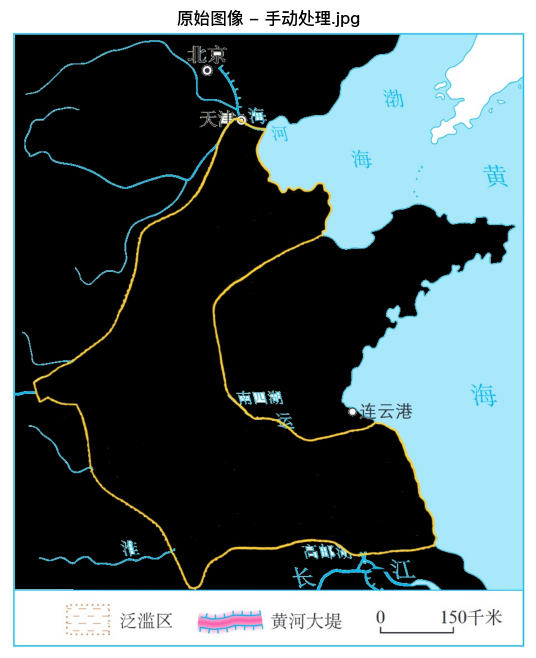

In [13]:
# 读取图像
image_path = "手动处理.jpg"

# 使用多种方法确保图像成功读取
image = None
try:
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("OpenCV读取失败")
    print(f"使用OpenCV成功读取图像：{image_path}")
except:
    try:
        pil_image = PILImage.open(image_path)
        if pil_image.mode == 'RGBA':
            pil_image = pil_image.convert('RGB')
        elif pil_image.mode != 'RGB':
            pil_image = pil_image.convert('RGB')
        
        image_rgb_pil = np.array(pil_image)
        image = cv2.cvtColor(image_rgb_pil, cv2.COLOR_RGB2BGR)
        print(f"使用PIL成功读取图像：{image_path}")
    except Exception as e:
        raise ValueError(f"无法读取图像文件 '{image_path}': {e}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]

print(f"图像尺寸: {width} x {height}")

# 显示原始图像
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title(f"原始图像 - {image_path}")
plt.axis('off')
plt.show()

## 3. 黄色区域检测和轮廓提取

黄色像素数量: 13152
黄色像素比例: 1.25%
原始掩膜: 58 个轮廓, 1 个主要轮廓
  最大轮廓面积: 250639

选择策略: 原始掩膜
最终保留 1 个主要轮廓


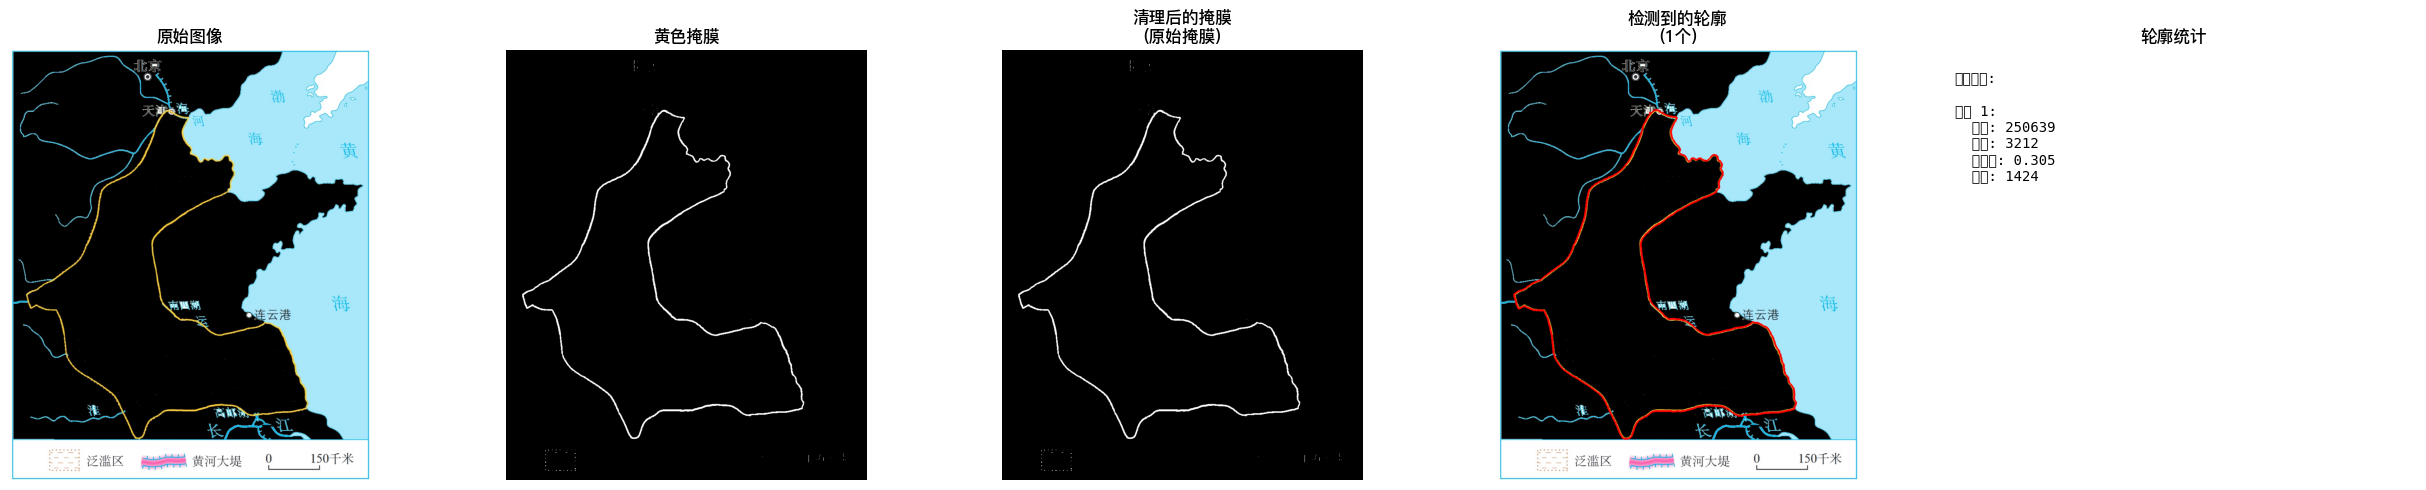


详细轮廓分析:
轮廓 1:
  面积: 250639 像素
  周长: 3212 像素
  顶点数: 1424
  是否闭合: False
  凸度: 0.652
  边界框: (42, 155, 734, 858)



In [14]:
# 转换到HSV色彩空间检测黄色
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# 定义多个黄色的HSV范围，提高检测准确性
lower_yellow1 = np.array([15, 100, 100])
upper_yellow1 = np.array([35, 255, 255])

# 备用范围（更宽泛的黄色检测）
lower_yellow2 = np.array([10, 80, 80])
upper_yellow2 = np.array([40, 255, 255])

# 创建黄色掩膜
yellow_mask1 = cv2.inRange(hsv, lower_yellow1, upper_yellow1)
yellow_mask2 = cv2.inRange(hsv, lower_yellow2, upper_yellow2)

# 合并两个掩膜
yellow_mask = cv2.bitwise_or(yellow_mask1, yellow_mask2)

print(f"黄色像素数量: {np.sum(yellow_mask > 0)}")
print(f"黄色像素比例: {np.sum(yellow_mask > 0) / (height * width) * 100:.2f}%")

# 形态学操作清理掩膜 - 多种策略
kernel_small = np.ones((3,3), np.uint8)
kernel_medium = np.ones((5,5), np.uint8)
kernel_large = np.ones((7,7), np.uint8)

# 策略1: 先填充小洞，再去除噪声
yellow_mask_v1 = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel_medium)
yellow_mask_v1 = cv2.morphologyEx(yellow_mask_v1, cv2.MORPH_OPEN, kernel_small)

# 策略2: 更强的清理
yellow_mask_v2 = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel_large)
yellow_mask_v2 = cv2.morphologyEx(yellow_mask_v2, cv2.MORPH_OPEN, kernel_medium)

# 策略3: 保持原始掩膜
yellow_mask_v3 = yellow_mask.copy()

# 测试不同策略的轮廓数量
strategies = [
    ("原始掩膜", yellow_mask_v3),
    ("轻度清理", yellow_mask_v1), 
    ("强度清理", yellow_mask_v2)
]

best_mask = None
best_contours = []
best_strategy = ""

for strategy_name, mask in strategies:
    contours_test, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_test = sorted(contours_test, key=cv2.contourArea, reverse=True)
    main_contours_test = [c for c in contours_test if cv2.contourArea(c) > 500]
    
    print(f"{strategy_name}: {len(contours_test)} 个轮廓, {len(main_contours_test)} 个主要轮廓")
    
    if len(main_contours_test) > 0:
        largest_area = cv2.contourArea(main_contours_test[0])
        print(f"  最大轮廓面积: {largest_area:.0f}")
        
        # 选择有合适数量轮廓的策略
        if 1 <= len(main_contours_test) <= 5 and largest_area > 10000:
            best_mask = mask
            best_contours = main_contours_test
            best_strategy = strategy_name
            break

# 如果没有找到合适的策略，使用原始掩膜
if best_mask is None:
    print("使用原始掩膜作为后备方案")
    best_mask = yellow_mask_v3
    contours, _ = cv2.findContours(best_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    best_contours = [c for c in best_contours if cv2.contourArea(c) > 500]
    best_strategy = "原始掩膜(后备)"

print(f"\n选择策略: {best_strategy}")
print(f"最终保留 {len(best_contours)} 个主要轮廓")

# 使用最佳结果
yellow_mask_cleaned = best_mask
contours = best_contours
main_contours = best_contours

# 显示处理过程
plt.figure(figsize=(25, 5))

plt.subplot(1, 5, 1)
plt.imshow(image_rgb)
plt.title("原始图像")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(yellow_mask, cmap='gray')
plt.title("黄色掩膜")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(yellow_mask_cleaned, cmap='gray')
plt.title(f"清理后的掩膜\n({best_strategy})")
plt.axis('off')

plt.subplot(1, 5, 4)
contour_img = image_rgb.copy()
cv2.drawContours(contour_img, main_contours, -1, (255, 0, 0), 3)
plt.imshow(contour_img)
plt.title(f"检测到的轮廓\n({len(main_contours)}个)")
plt.axis('off')

# 显示轮廓详细信息
plt.subplot(1, 5, 5)
plt.axis('off')
info_text = "轮廓信息:\n\n"
for i, contour in enumerate(main_contours[:5]):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    # 计算轮廓的紧密度
    compactness = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
    info_text += f"轮廓 {i+1}:\n"
    info_text += f"  面积: {area:.0f}\n"
    info_text += f"  周长: {perimeter:.0f}\n"
    info_text += f"  紧密度: {compactness:.3f}\n"
    info_text += f"  点数: {len(contour)}\n\n"

plt.text(0.05, 0.95, info_text, transform=plt.gca().transAxes, 
         verticalalignment='top', fontsize=10, family='monospace')
plt.title("轮廓统计")

plt.tight_layout()
plt.show()

# 打印详细的轮廓信息
print(f"\n详细轮廓分析:")
for i, contour in enumerate(main_contours[:3]):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    # 检查轮廓是否闭合
    is_closed = np.array_equal(contour[0], contour[-1])
    
    # 计算轮廓的凸包
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    convexity = area / hull_area if hull_area > 0 else 0
    
    print(f"轮廓 {i+1}:")
    print(f"  面积: {area:.0f} 像素")
    print(f"  周长: {perimeter:.0f} 像素") 
    print(f"  顶点数: {len(contour)}")
    print(f"  是否闭合: {is_closed}")
    print(f"  凸度: {convexity:.3f}")
    print(f"  边界框: {cv2.boundingRect(contour)}")
    print()

## 4. 轮廓连接和闭合处理

In [15]:
def connect_nearby_contours(contours, max_distance=50):
    """
    连接距离较近的轮廓端点
    """
    if len(contours) <= 1:
        return contours
    
    # 将所有轮廓点合并
    all_points = []
    contour_indices = []
    
    for i, contour in enumerate(contours):
        points = contour.reshape(-1, 2)
        all_points.extend(points)
        contour_indices.extend([i] * len(points))
    
    return all_points, contour_indices

def create_polygon_from_contour(contour, min_area=100):
    """
    从单个轮廓创建多边形，使用多种策略
    """
    try:
        points = contour.reshape(-1, 2)
        print(f"  轮廓原始点数: {len(points)}")
        
        # 策略1: 直接转换
        coords = [(float(x), float(height - y)) for x, y in points]
        
        # 确保多边形闭合
        if len(coords) >= 3:
            if coords[0] != coords[-1]:
                coords.append(coords[0])
            
            # 尝试创建多边形
            try:
                poly = Polygon(coords)
                print(f"  原始多边形: 有效={poly.is_valid}, 面积={poly.area:.0f}")
                
                if poly.is_valid and poly.area > min_area:
                    return poly
                elif not poly.is_valid:
                    # 尝试修复无效多边形
                    try:
                        # 使用buffer(0)修复自相交
                        fixed_poly = poly.buffer(0)
                        if hasattr(fixed_poly, 'area') and fixed_poly.area > min_area:
                            print(f"  修复后多边形: 面积={fixed_poly.area:.0f}")
                            return fixed_poly
                    except:
                        pass
                        
            except Exception as e:
                print(f"  创建多边形失败: {e}")
        
        # 策略2: 简化轮廓后再创建
        epsilon = 0.001 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        if len(approx) >= 3:
            points_simplified = approx.reshape(-1, 2)
            coords_simplified = [(float(x), float(height - y)) for x, y in points_simplified]
            
            if coords_simplified[0] != coords_simplified[-1]:
                coords_simplified.append(coords_simplified[0])
                
            try:
                poly_simplified = Polygon(coords_simplified)
                print(f"  简化多边形: 有效={poly_simplified.is_valid}, 面积={poly_simplified.area:.0f}, 点数={len(coords_simplified)}")
                
                if poly_simplified.is_valid and poly_simplified.area > min_area:
                    return poly_simplified
            except Exception as e:
                print(f"  简化多边形失败: {e}")
        
        # 策略3: 使用凸包
        try:
            hull = cv2.convexHull(contour)
            hull_points = hull.reshape(-1, 2)
            hull_coords = [(float(x), float(height - y)) for x, y in hull_points]
            
            if len(hull_coords) >= 3:
                if hull_coords[0] != hull_coords[-1]:
                    hull_coords.append(hull_coords[0])
                    
                poly_hull = Polygon(hull_coords)
                print(f"  凸包多边形: 有效={poly_hull.is_valid}, 面积={poly_hull.area:.0f}")
                
                if poly_hull.is_valid and poly_hull.area > min_area:
                    return poly_hull
        except Exception as e:
            print(f"  凸包多边形失败: {e}")
            
    except Exception as e:
        print(f"  轮廓处理失败: {e}")
    
    return None

def create_unified_polygon(contours):
    """
    将多个轮廓合并为一个统一的多边形，使用改进的策略
    """
    if not contours:
        print("❌ 没有输入轮廓")
        return None
    
    print(f"\n🔄 开始处理 {len(contours)} 个轮廓...")
    
    # 转换为shapely多边形
    polygons = []
    
    for i, contour in enumerate(contours):
        print(f"\n处理轮廓 {i+1}/{len(contours)}:")
        area = cv2.contourArea(contour)
        print(f"  轮廓面积: {area:.0f}")
        
        if area < 100:  # 跳过太小的轮廓
            print("  跳过: 面积太小")
            continue
            
        poly = create_polygon_from_contour(contour, min_area=100)
        if poly:
            polygons.append(poly)
            print(f"  ✅ 成功创建多边形: 面积={poly.area:.0f}, 周长={poly.length:.0f}")
        else:
            print("  ❌ 创建多边形失败")
    
    if not polygons:
        print("❌ 没有创建成功任何多边形")
        return None
    
    print(f"\n📊 成功创建 {len(polygons)} 个多边形")
    for i, poly in enumerate(polygons):
        print(f"  多边形 {i+1}: 面积={poly.area:.0f}, 周长={poly.length:.0f}, 有效={poly.is_valid}")
    
    # 合并所有多边形
    try:
        if len(polygons) == 1:
            unified_polygon = polygons[0]
            print(f"\n✅ 使用单个多边形")
        else:
            print(f"\n🔗 合并 {len(polygons)} 个多边形...")
            
            # 策略1: 使用unary_union
            try:
                unified_polygon = unary_union(polygons)
                print(f"  unary_union结果类型: {type(unified_polygon)}")
                
                # 如果结果是MultiPolygon，取最大的一个
                if isinstance(unified_polygon, MultiPolygon):
                    unified_polygon = max(unified_polygon.geoms, key=lambda p: p.area)
                    print(f"  从MultiPolygon中选择最大多边形")
                    
            except Exception as e:
                print(f"  unary_union失败: {e}")
                # 后备策略：使用最大的多边形
                unified_polygon = max(polygons, key=lambda p: p.area)
                print(f"  使用最大多边形作为结果")
        
        if unified_polygon and hasattr(unified_polygon, 'area'):
            print(f"\n🎯 最终多边形:")
            print(f"   面积: {unified_polygon.area:.0f}")
            print(f"   周长: {unified_polygon.length:.0f}")
            print(f"   有效性: {unified_polygon.is_valid}")
            print(f"   边界框: {unified_polygon.bounds}")
            if hasattr(unified_polygon, 'exterior') and unified_polygon.exterior:
                print(f"   坐标点数: {len(list(unified_polygon.exterior.coords))}")
            return unified_polygon
        else:
            print("❌ 合并结果无效")
            return None
            
    except Exception as e:
        print(f"❌ 合并多边形失败: {e}")
        # 最后的后备策略
        if polygons:
            backup_polygon = max(polygons, key=lambda p: p.area)
            print(f"🔄 使用面积最大的多边形作为后备: 面积={backup_polygon.area:.0f}")
            return backup_polygon
        return None

# 创建统一的多边形
print("="*60)
print("🚀 开始创建统一多边形")
print("="*60)

unified_polygon = create_unified_polygon(main_contours)

if unified_polygon:
    print(f"\n" + "="*60)
    print("✅ 成功创建统一多边形!")
    print("="*60)
    print(f"   面积: {unified_polygon.area:.0f} 平方像素")
    print(f"   周长: {unified_polygon.length:.0f} 像素")
    if hasattr(unified_polygon, 'exterior') and unified_polygon.exterior:
        print(f"   坐标点数: {len(list(unified_polygon.exterior.coords))}")
    print(f"   几何有效性: {'✅ 有效' if unified_polygon.is_valid else '❌ 无效'}")
    print(f"   边界框: {unified_polygon.bounds}")
else:
    print(f"\n" + "="*60)
    print("❌ 未能创建有效的多边形")
    print("="*60)
    print("可能的原因:")
    print("1. 轮廓太小或太复杂")
    print("2. 轮廓不闭合或自相交")
    print("3. 坐标转换问题")
    print("4. 需要调整HSV颜色范围")

🚀 开始创建统一多边形

🔄 开始处理 1 个轮廓...

处理轮廓 1/1:
  轮廓面积: 250639
  轮廓原始点数: 1424
  原始多边形: 有效=False, 面积=250639
  修复后多边形: 面积=250639
  ✅ 成功创建多边形: 面积=250639, 周长=3208

📊 成功创建 1 个多边形
  多边形 1: 面积=250639, 周长=3208, 有效=True

✅ 使用单个多边形

🎯 最终多边形:
   面积: 250639
   周长: 3208
   有效性: True
   边界框: (42.0, 108.0, 775.0, 965.0)
   坐标点数: 1424

✅ 成功创建统一多边形!
   面积: 250639 平方像素
   周长: 3208 像素
   坐标点数: 1424
   几何有效性: ✅ 有效
   边界框: (42.0, 108.0, 775.0, 965.0)


## 5. 多边形优化和验证

多边形简化: 1424 → 102 个点

📊 最终多边形信息:
   面积: 250573
   周长: 3012
   边界点数: 102
   是否有效: True
   边界框: (42.0, 109.0, 775.0, 965.0)


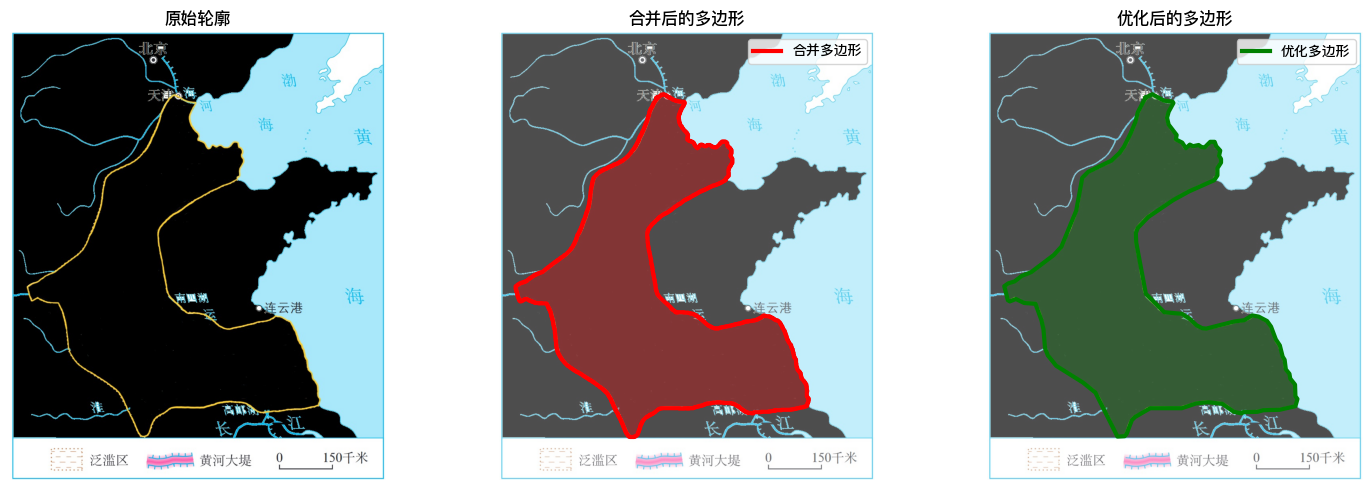

In [16]:
def optimize_polygon(polygon, simplify_tolerance=2.0):
    """
    优化多边形：简化、修复等
    """
    if not polygon or not polygon.is_valid:
        return None
    
    try:
        # 简化多边形（减少点数）
        simplified = polygon.simplify(simplify_tolerance, preserve_topology=True)
        
        # 确保多边形有效
        if simplified.is_valid:
            print(f"多边形简化: {len(list(polygon.exterior.coords))} → {len(list(simplified.exterior.coords))} 个点")
            return simplified
        else:
            print("简化后的多边形无效，返回原多边形")
            return polygon
            
    except Exception as e:
        print(f"多边形优化失败: {e}")
        return polygon

# 优化多边形
if unified_polygon:
    optimized_polygon = optimize_polygon(unified_polygon)
    
    if optimized_polygon:
        print(f"\n📊 最终多边形信息:")
        print(f"   面积: {optimized_polygon.area:.0f}")
        print(f"   周长: {optimized_polygon.length:.0f}")
        print(f"   边界点数: {len(list(optimized_polygon.exterior.coords))}")
        print(f"   是否有效: {optimized_polygon.is_valid}")
        print(f"   边界框: {optimized_polygon.bounds}")
        
        # 可视化结果
        plt.figure(figsize=(15, 5))
        
        # 原始轮廓
        plt.subplot(1, 3, 1)
        plt.imshow(image_rgb)
        cv2.drawContours(image_rgb.copy(), main_contours, -1, (255, 0, 0), 3)
        plt.title("原始轮廓")
        plt.axis('off')
        
        # 统一多边形
        plt.subplot(1, 3, 2)
        plt.imshow(image_rgb, alpha=0.7)
        if unified_polygon.exterior:
            x_coords, y_coords = unified_polygon.exterior.xy
            # 转换回图像坐标
            y_coords_img = [height - y for y in y_coords]
            plt.plot(x_coords, y_coords_img, 'r-', linewidth=3, label='合并多边形')
            plt.fill(x_coords, y_coords_img, 'red', alpha=0.3)
        plt.title("合并后的多边形")
        plt.legend()
        plt.axis('off')
        
        # 优化后多边形
        plt.subplot(1, 3, 3)
        plt.imshow(image_rgb, alpha=0.7)
        if optimized_polygon.exterior:
            x_coords, y_coords = optimized_polygon.exterior.xy
            # 转换回图像坐标
            y_coords_img = [height - y for y in y_coords]
            plt.plot(x_coords, y_coords_img, 'g-', linewidth=3, label='优化多边形')
            plt.fill(x_coords, y_coords_img, 'green', alpha=0.3)
        plt.title("优化后的多边形")
        plt.legend()
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("❌ 多边形优化失败")
        optimized_polygon = unified_polygon
else:
    print("❌ 没有可用的多边形进行优化")
    optimized_polygon = None

## 6. 保存为ArcMap面文件

In [17]:
# 保存为Shapefile面要素
if optimized_polygon and optimized_polygon.is_valid:
    try:
        # 创建GeoDataFrame
        gdf_data = {
            'ID': [1],
            'NAME': ['黄色边界区域'],
            'AREA': [round(optimized_polygon.area, 2)],
            'PERIMETER': [round(optimized_polygon.length, 2)],
            'VERTICES': [len(list(optimized_polygon.exterior.coords))],
            'SOURCE': [image_path],
            'TYPE': ['BOUNDARY_POLYGON']
        }
        
        gdf = gpd.GeoDataFrame(gdf_data, geometry=[optimized_polygon])
        
        # 设置坐标系（图像坐标系）
        # gdf.crs = 'EPSG:4326'  # 如果需要地理坐标系，取消注释
        
        # 保存文件路径
        shapefile_path = os.path.join(output_dir, "黄色边界面要素.shp")
        geojson_path = os.path.join(output_dir, "黄色边界面要素.geojson")
        
        # 保存为Shapefile
        gdf.to_file(shapefile_path, encoding='utf-8')
        print(f"✅ 已保存Shapefile: {shapefile_path}")
        
        # 保存为GeoJSON
        gdf.to_file(geojson_path, driver='GeoJSON')
        print(f"✅ 已保存GeoJSON: {geojson_path}")
        
        # 显示属性表
        print(f"\n📋 面要素属性表:")
        print(gdf)
        
        print(f"\n🗂️ 生成的文件:")
        output_files = os.listdir(output_dir)
        for file in sorted(output_files):
            if file.startswith("黄色边界面要素"):
                file_path = os.path.join(output_dir, file)
                file_size = os.path.getsize(file_path) / 1024  # KB
                print(f"   {file} ({file_size:.1f} KB)")
        
    except Exception as e:
        print(f"❌ 保存Shapefile时出错: {e}")
        
else:
    print("❌ 没有有效的多边形可以保存")

✅ 已保存Shapefile: output/黄色边界面要素.shp
✅ 已保存GeoJSON: output/黄色边界面要素.geojson

📋 面要素属性表:
   ID    NAME      AREA  PERIMETER  VERTICES    SOURCE              TYPE  \
0   1  黄色边界区域  250573.0    3012.08       102  手动处理.jpg  BOUNDARY_POLYGON   

                                            geometry  
0  POLYGON ((395 956, 412 965, 441 949, 463 946, ...  

🗂️ 生成的文件:
   黄色边界面要素.cpg (0.0 KB)
   黄色边界面要素.dbf (0.6 KB)
   黄色边界面要素.geojson (2.1 KB)
   黄色边界面要素.shp (1.7 KB)
   黄色边界面要素.shx (0.1 KB)


## 7. 保存其他格式文件

In [18]:
# 保存坐标数据为其他格式
if optimized_polygon and optimized_polygon.is_valid:
    
    # 提取外边界坐标
    exterior_coords = list(optimized_polygon.exterior.coords)
    
    # 1. 保存为CSV格式
    csv_data = []
    for i, (x, y) in enumerate(exterior_coords):
        csv_data.append({
            'PointID': i + 1,
            'X': x,
            'Y': y,
            'PolygonID': 1,
            'PolygonName': '黄色边界区域'
        })
    
    df_coords = pd.DataFrame(csv_data)
    csv_path = os.path.join(output_dir, "黄色边界面要素坐标.csv")
    df_coords.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"✅ 已保存CSV文件: {csv_path}")
    print(f"   包含 {len(df_coords)} 个边界点")
    
    # 2. 保存为JSON格式
    json_data = {
        'metadata': {
            'source_image': image_path,
            'image_size': {'width': width, 'height': height},
            'extraction_date': pd.Timestamp.now().isoformat(),
            'description': '黄色边界面要素提取结果',
            'coordinate_system': 'image_coordinates'
        },
        'polygon': {
            'id': 1,
            'name': '黄色边界区域',
            'properties': {
                'area': optimized_polygon.area,
                'perimeter': optimized_polygon.length,
                'vertex_count': len(exterior_coords),
                'is_valid': optimized_polygon.is_valid,
                'bounds': optimized_polygon.bounds
            },
            'exterior_coordinates': exterior_coords,
            'interior_coordinates': [list(interior.coords) for interior in optimized_polygon.interiors] if optimized_polygon.interiors else []
        }
    }
    
    json_path = os.path.join(output_dir, "黄色边界面要素.json")
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2, ensure_ascii=False)
    
    print(f"✅ 已保存JSON文件: {json_path}")
    
    # 3. 保存为文本格式（ArcMap ASCII格式）
    txt_path = os.path.join(output_dir, "黄色边界面要素坐标.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("# 黄色边界面要素坐标\n")
        f.write(f"# 源图像: {image_path}\n")
        f.write(f"# 图像尺寸: {width} x {height}\n")
        f.write(f"# 提取时间: {pd.Timestamp.now()}\n")
        f.write(f"# 面积: {optimized_polygon.area:.2f}\n")
        f.write(f"# 周长: {optimized_polygon.length:.2f}\n")
        f.write("# 格式: PointID, X, Y\n")
        f.write("\n")
        
        for i, (x, y) in enumerate(exterior_coords):
            f.write(f"{i+1}, {x:.6f}, {y:.6f}\n")
    
    print(f"✅ 已保存文本文件: {txt_path}")
    
    # 显示CSV前几行
    print("\n📋 CSV文件前5行:")
    print(df_coords.head())
    
else:
    print("❌ 没有有效的多边形数据可以保存")

✅ 已保存CSV文件: output/黄色边界面要素坐标.csv
   包含 102 个边界点
✅ 已保存JSON文件: output/黄色边界面要素.json
✅ 已保存文本文件: output/黄色边界面要素坐标.txt

📋 CSV文件前5行:
   PointID      X      Y  PolygonID PolygonName
0        1  395.0  956.0          1      黄色边界区域
1        2  412.0  965.0          1      黄色边界区域
2        3  441.0  949.0          1      黄色边界区域
3        4  463.0  946.0          1      黄色边界区域
4        5  465.0  943.0          1      黄色边界区域


## 8. 最终结果展示和总结

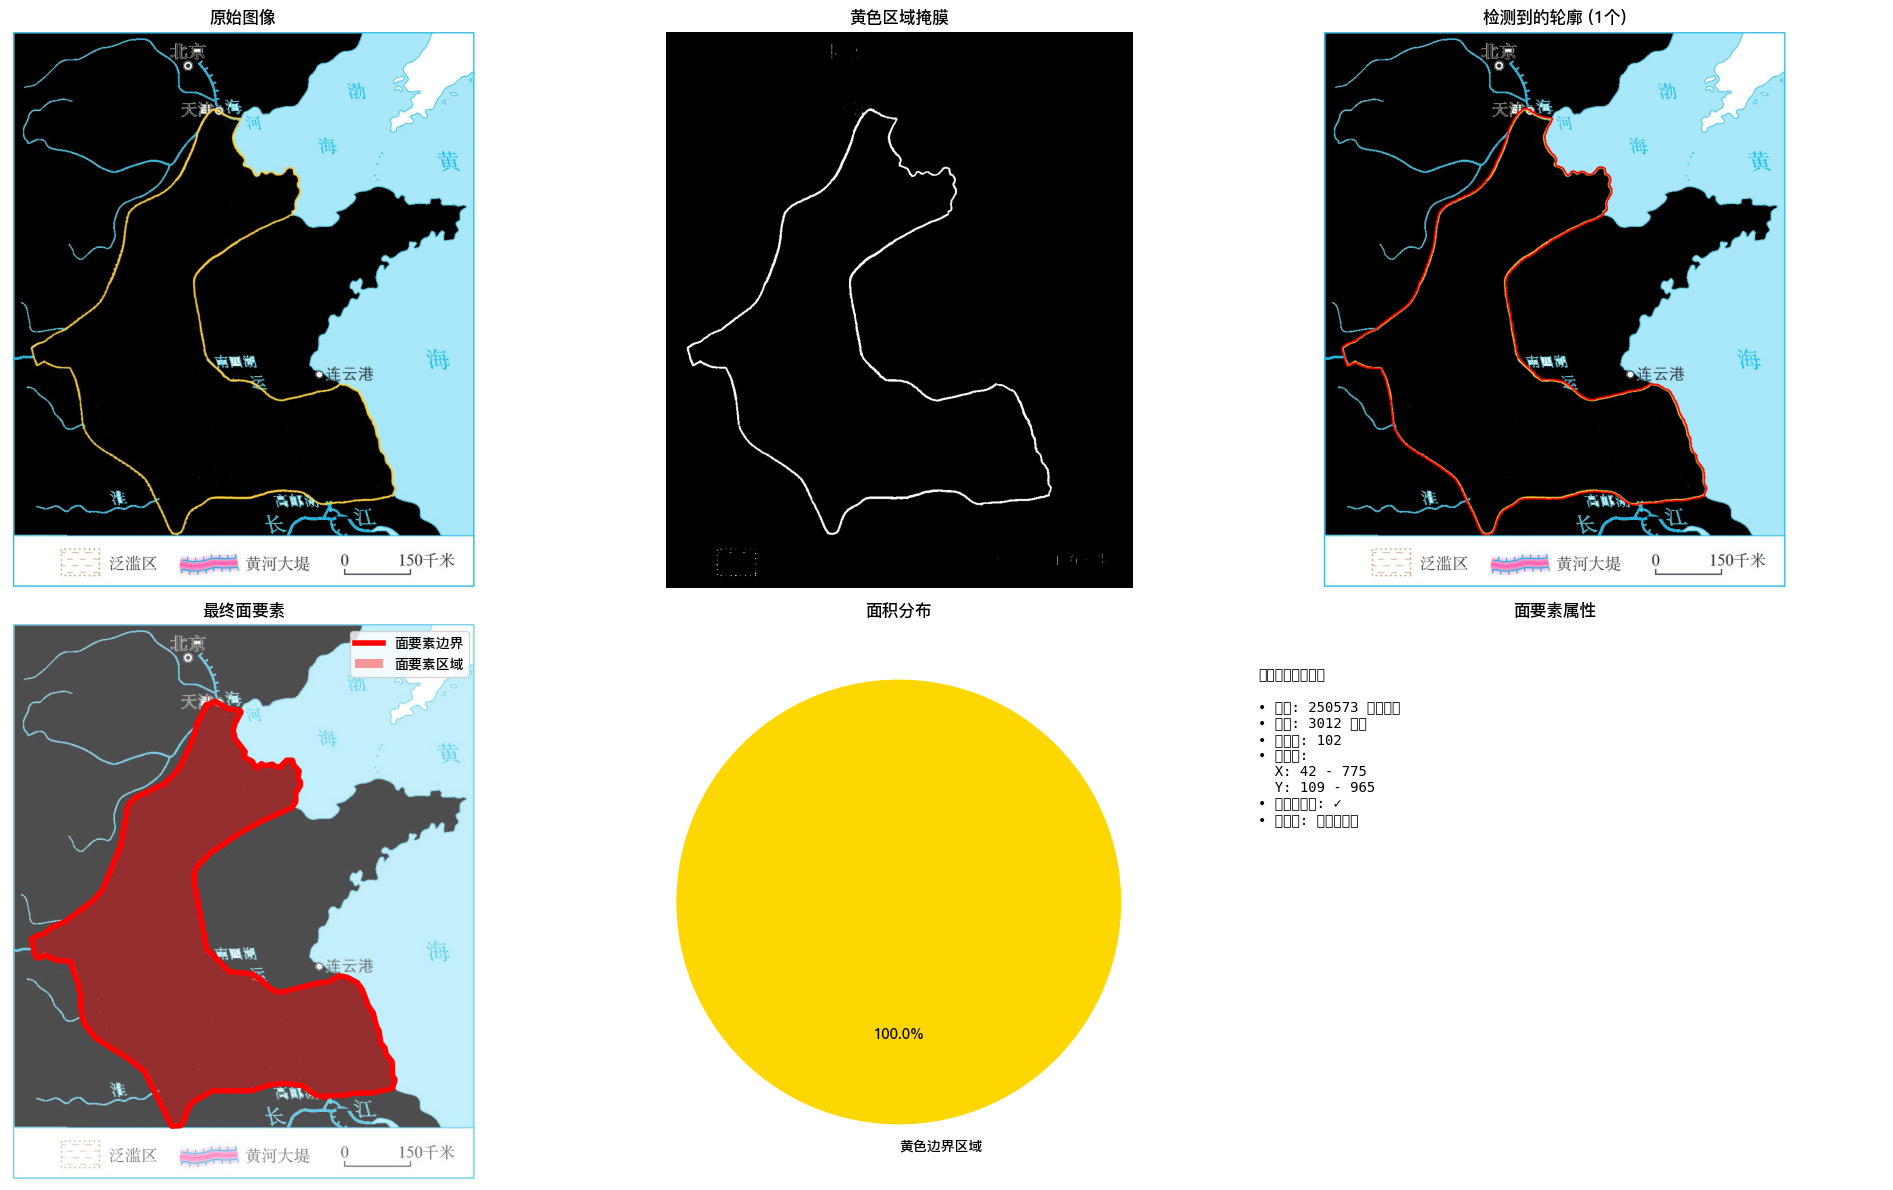


🎯 黄色边界面要素提取完成

📁 输出目录: /workspaces/images/output

📂 生成的文件:
   1. 黄色边界面要素.cpg (0.0 KB)
   2. 黄色边界面要素.dbf (0.6 KB)
   3. 黄色边界面要素.geojson (2.1 KB)
   4. 黄色边界面要素.json (5.2 KB)
   5. 黄色边界面要素.shp (1.7 KB)
   6. 黄色边界面要素.shx (0.1 KB)
   7. 黄色边界面要素坐标.csv (3.6 KB)
   8. 黄色边界面要素坐标.txt (2.9 KB)

📊 面要素统计:
   • 数量: 1 个面要素
   • 面积: 250573 平方像素
   • 周长: 3012 像素
   • 顶点: 102 个
   • 有效性: ✓ 有效

🗺️ ArcMap导入指南:
   1. 打开ArcMap
   2. 点击 'Add Data' 按钮
   3. 导航到: /workspaces/images/output
   4. 选择: 黄色边界面要素.shp
   5. 点击 'Add' 添加到地图
   6. 面要素将显示为多边形
   7. 右键图层 → Properties → Symbology 设置样式
   8. 右键图层 → Open Attribute Table 查看属性

⚙️ 注意事项:
   • 当前使用图像坐标系（像素坐标）
   • 如需地理坐标，请在ArcMap中进行坐标转换
   • 可通过地理配准将图像与实际地理位置对应
   • 属性表包含面积、周长、顶点数等详细信息

✅ 提取成功! 已生成有效的面要素文件


In [19]:
# 创建最终结果可视化
plt.figure(figsize=(20, 12))

# 原始图像
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("原始图像")
plt.axis('off')

# 黄色掩膜
plt.subplot(2, 3, 2)
plt.imshow(yellow_mask_cleaned, cmap='gray')
plt.title("黄色区域掩膜")
plt.axis('off')

# 检测的轮廓
plt.subplot(2, 3, 3)
contour_img = image_rgb.copy()
cv2.drawContours(contour_img, main_contours, -1, (255, 0, 0), 2)
plt.imshow(contour_img)
plt.title(f"检测到的轮廓 ({len(main_contours)}个)")
plt.axis('off')

# 最终面要素
plt.subplot(2, 3, 4)
plt.imshow(image_rgb, alpha=0.7)
if optimized_polygon and optimized_polygon.is_valid:
    x_coords, y_coords = optimized_polygon.exterior.xy
    # 转换回图像坐标
    y_coords_img = [height - y for y in y_coords]
    plt.plot(x_coords, y_coords_img, 'r-', linewidth=4, label='面要素边界')
    plt.fill(x_coords, y_coords_img, 'red', alpha=0.4, label='面要素区域')
plt.title("最终面要素")
plt.legend()
plt.axis('off')

# 面积统计图
plt.subplot(2, 3, 5)
if optimized_polygon:
    areas = [optimized_polygon.area]
    labels = ['黄色边界区域']
    colors = ['gold']
    
    plt.pie(areas, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('面积分布')
else:
    plt.text(0.5, 0.5, '无有效面要素', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('面积分布')

# 属性信息
plt.subplot(2, 3, 6)
plt.axis('off')
if optimized_polygon:
    info_text = f"""
面要素属性信息：

• 面积: {optimized_polygon.area:.0f} 平方像素
• 周长: {optimized_polygon.length:.0f} 像素
• 顶点数: {len(list(optimized_polygon.exterior.coords))}
• 边界框: 
  X: {optimized_polygon.bounds[0]:.0f} - {optimized_polygon.bounds[2]:.0f}
  Y: {optimized_polygon.bounds[1]:.0f} - {optimized_polygon.bounds[3]:.0f}
• 几何有效性: {'✓' if optimized_polygon.is_valid else '✗'}
• 坐标系: 图像坐标系
"""
    plt.text(0.05, 0.95, info_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontsize=10, family='monospace')
else:
    plt.text(0.5, 0.5, '无有效面要素信息', ha='center', va='center', transform=plt.gca().transAxes)

plt.title('面要素属性')

plt.tight_layout()
plt.show()

# 打印最终总结
print("\n" + "="*80)
print("🎯 黄色边界面要素提取完成")
print("="*80)

print(f"\n📁 输出目录: {os.path.abspath(output_dir)}")
print(f"\n📂 生成的文件:")
output_files = [f for f in os.listdir(output_dir) if f.startswith("黄色边界面要素")]
for i, file in enumerate(sorted(output_files), 1):
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"   {i}. {file} ({file_size:.1f} KB)")

if optimized_polygon:
    print(f"\n📊 面要素统计:")
    print(f"   • 数量: 1 个面要素")
    print(f"   • 面积: {optimized_polygon.area:.0f} 平方像素")
    print(f"   • 周长: {optimized_polygon.length:.0f} 像素")
    print(f"   • 顶点: {len(list(optimized_polygon.exterior.coords))} 个")
    print(f"   • 有效性: {'✓ 有效' if optimized_polygon.is_valid else '✗ 无效'}")

print(f"\n🗺️ ArcMap导入指南:")
print(f"   1. 打开ArcMap")
print(f"   2. 点击 'Add Data' 按钮")
print(f"   3. 导航到: {os.path.abspath(output_dir)}")
print(f"   4. 选择: 黄色边界面要素.shp")
print(f"   5. 点击 'Add' 添加到地图")
print(f"   6. 面要素将显示为多边形")
print(f"   7. 右键图层 → Properties → Symbology 设置样式")
print(f"   8. 右键图层 → Open Attribute Table 查看属性")

print(f"\n⚙️ 注意事项:")
print(f"   • 当前使用图像坐标系（像素坐标）")
print(f"   • 如需地理坐标，请在ArcMap中进行坐标转换")
print(f"   • 可通过地理配准将图像与实际地理位置对应")
print(f"   • 属性表包含面积、周长、顶点数等详细信息")

if optimized_polygon and optimized_polygon.is_valid:
    print(f"\n✅ 提取成功! 已生成有效的面要素文件")
else:
    print(f"\n❌ 提取失败! 未能生成有效的面要素")